# Kernel Based Scores

**Theorem 15.** *If $h : \mathcal{Y} \times \mathcal{Y} \to [0,\infty)$ is a (strongly) conditionally negative definite kernel, then the scoring rule $S : \mathcal{P}_h \times \mathcal{Y} \to \overline{\mathbb{R}}$ given by*

$$
S(\mathbb{P}, y) = \int h(y, x) \, \mathrm{d}\mathbb{P}(x) - \frac{1}{2} \iint h(x, x') \, \mathrm{d}\mathbb{P}(x) \, \mathrm{d}\mathbb{P}(x') \tag{12}
$$

*is (strictly) proper.* 

This can be estimated by 
$$
\hat{S}(\mathbb{P}, y) = \frac{1}{m} \sum_{i=1}^{m} h(X_i, y) - \frac{1}{2m(m-1)} \sum_{i=1}^{m} \sum_{i':i' \neq i} h(X_i, X_{i'})
$$
Waghmare and Ziegel (2025)

## RBF Kernel Scores
In our case we define $h$ as the negative rbf kernel:
$$
\operatorname{rbf}(X_i,y) = -\exp(\frac{-{\lVert X_i-y\rVert}^2}{\gamma})
$$
But our samples are images, i.e. $X_i \in \mathbb{R}^{c \times h \times w}$.  
Flattening and then computing $h(\operatorname{flatten}(X_i), \operatorname{flatten}(y))$ destroys the spatial connections we need.

Thus we need a kernel that takes the spatial dependencies into account.  
We do this by spltting the image into patches and then calculating $h$ per patch and taking the mean.
$$
\operatorname{patchwise\_rbf}(X_i, y) = \frac{1}{\lvert \mathcal{P} \rvert} \sum_{p \in \mathcal{P}} \operatorname{rbf}(X_i^p, y^p) = \frac{1}{\lvert \mathcal{P} \rvert} \sum_{p \in \mathcal{P}} -\exp(\frac{-{\lVert X_i^p-y^p\rVert}^2}{\gamma})
$$

Thus the final score is
$$
\hat{S}(\mathbb{P}, y) = \frac{1}{m} \sum_{i=1}^{m} \frac{1}{\lvert \mathcal{P} \rvert} \sum_{p \in \mathcal{P}} -\exp(\frac{-{\lVert X_i^p-y^p\rVert}^2}{\gamma}) - \frac{1}{2m(m-1)} \sum_{i=1}^{m} \sum_{i':i' \neq i} \frac{1}{\lvert \mathcal{P} \rvert} \sum_{p \in \mathcal{P}} -\exp(\frac{-{\lVert X_i^p-X_{i'}^p\rVert}^2}{\gamma})
$$

Is this the same as 
$$
\hat{S}(\mathbb{P}, y) = \frac{1}{\lvert \mathcal{P} \rvert} \sum_{p \in \mathcal{P}} \left(\frac{1}{m} \sum_{i=1}^{m} -\exp(\frac{-{\lVert X_i^p-y^p\rVert}^2}{\gamma}) - \frac{1}{2m(m-1)} \sum_{i=1}^{m} \sum_{i':i' \neq i} -\exp(\frac{-{\lVert X_i^p-X_{i'}^p\rVert}^2}{\gamma})\right)
$$
since the sums can be swapped.

In [1]:
%load_ext autoreload
%autoreload 2

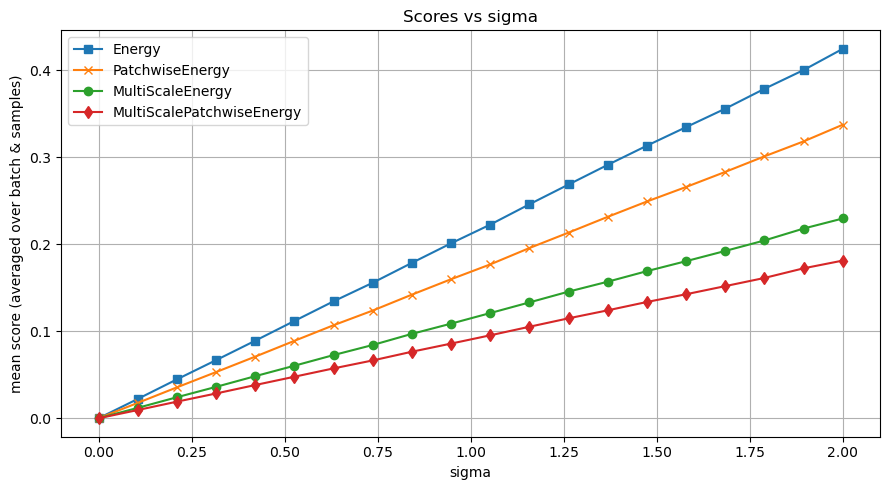

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from genpp.models.scores import (
    EnergyScore,
    PatchwiseEnergyScore,
    MultiScaleEnergyScore,
    MultiScalePatchwiseEnergyScore,
)

# reproducibility
torch.manual_seed(0)

b = 8
n = 25
c = 2
h = 20
w = 20

es = EnergyScore(normalize=True, beta=1.0)
pes = PatchwiseEnergyScore(patch_size=5, normalize=True, beta=1.0)
ms_es = MultiScaleEnergyScore(blur_kernel_sizes=[3, 7], normalize=True, beta=1.0)
ms_pes = MultiScalePatchwiseEnergyScore(
    patch_size=5, blur_kernel_sizes=[3, 7], normalize=True, beta=1.0
)

sigmas = torch.linspace(0, 2, 20)
es_vals, pes_vals, ms_es_vals, ms_pes_vals = [], [], [], []

for sigma in sigmas:
    y = torch.randn(b, c, h, w)  # shape [b, c, h, w]
    x = y.unsqueeze(1) + torch.randn(b, n, c, h, w) * sigma  # shape [b, n, c, h, w]

    # apply lower triangular mask to simulate data with a spatial pattern
    mask = torch.tril(torch.ones(h, w)).unsqueeze(0).unsqueeze(0)  # shape [1, 1, h, w]
    y = y * mask
    x = x * mask.unsqueeze(1)  # shape [b, n, c, h, w]

    es_res = es(x, y, mode="complete")
    pes_res = pes(x, y, mode="complete")
    ms_es_res = ms_es(x, y, mode="complete")
    ms_pes_res = ms_pes(x, y, mode="complete")

    es_vals.append(es_res.mean().item())
    pes_vals.append(pes_res.mean().item())
    ms_es_vals.append(ms_es_res.mean().item())
    ms_pes_vals.append(ms_pes_res.mean().item())

sigmas_np = sigmas.numpy()
es_vals = np.array(es_vals)
pes_vals = np.array(pes_vals)
ms_es_vals = np.array(ms_es_vals)
ms_pes_vals = np.array(ms_pes_vals)

plt.figure(figsize=(9, 5))
plt.plot(sigmas_np, es_vals, marker="s", label="Energy")
plt.plot(sigmas_np, pes_vals, marker="x", label="PatchwiseEnergy")
plt.plot(sigmas_np, ms_es_vals, marker="o", label="MultiScaleEnergy")
plt.plot(sigmas_np, ms_pes_vals, marker="d", label="MultiScalePatchwiseEnergy")
plt.xlabel("sigma")
plt.ylabel("mean score (averaged over batch & samples)")
plt.title("Scores vs sigma")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

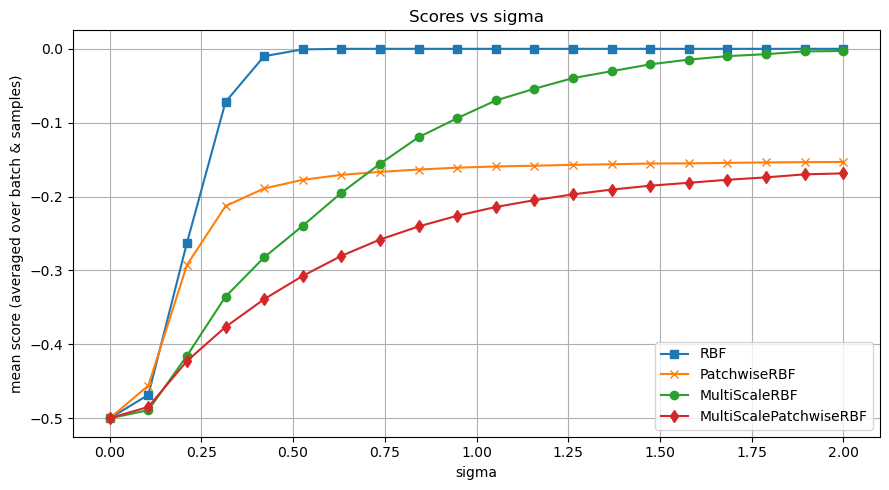

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from genpp.models.scores import (
    RBFScore,
    PatchwiseRBFScore,
    MultiScaleRBFScore,
    MultiScalePatchwiseRBFScore,
)

# reproducibility
torch.manual_seed(0)

b = 8
n = 25
c = 2
h = 20
w = 20

lengthscales = [0.1]

rbf = RBFScore(lengthscales=lengthscales)
prbf = PatchwiseRBFScore(lengthscales=lengthscales, patch_size=5)
ms_rbf = MultiScaleRBFScore(lengthscales=lengthscales, blur_kernel_sizes=[3, 7])
ms_prbf = MultiScalePatchwiseRBFScore(
    lengthscales=lengthscales, patch_size=5, blur_kernel_sizes=[3, 7]
)

sigmas = torch.linspace(0, 2, 20)
rbf_vals, prbf_vals, ms_rbf_vals, ms_prbf_vals = [], [], [], []

for sigma in sigmas:
    y = torch.randn(b, c, h, w)  # shape [b, c, h, w]
    x = y.unsqueeze(1) + torch.randn(b, n, c, h, w) * sigma  # shape [b, n, c, h, w]

    # apply lower triangular mask to simulate data with a spatial pattern
    mask = torch.tril(torch.ones(h, w)).unsqueeze(0).unsqueeze(0)  # shape [1, 1, h, w]
    y = y * mask
    x = x * mask.unsqueeze(1)  # shape [b, n, c, h, w]

    rbf_res = rbf(x, y, mode="complete")
    prbf_res = prbf(x, y, mode="complete")
    ms_rbf_res = ms_rbf(x, y, mode="complete")
    ms_prbf_res = ms_prbf(x, y, mode="complete")

    rbf_vals.append(rbf_res.mean().item())
    prbf_vals.append(prbf_res.mean().item())
    ms_rbf_vals.append(ms_rbf_res.mean().item())
    ms_prbf_vals.append(ms_prbf_res.mean().item())

sigmas_np = sigmas.numpy()
rbf_vals = np.array(rbf_vals)
prbf_vals = np.array(prbf_vals)
ms_rbf_vals = np.array(ms_rbf_vals)
ms_prbf_vals = np.array(ms_prbf_vals)

plt.figure(figsize=(9, 5))
plt.plot(sigmas_np, rbf_vals, marker="s", label="RBF")
plt.plot(sigmas_np, prbf_vals, marker="x", label="PatchwiseRBF")
plt.plot(sigmas_np, ms_rbf_vals, marker="o", label="MultiScaleRBF")
plt.plot(sigmas_np, ms_prbf_vals, marker="d", label="MultiScalePatchwiseRBF")
plt.xlabel("sigma")
plt.ylabel("mean score (averaged over batch & samples)")
plt.title("Scores vs sigma")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()